In [4]:
%reload_ext autoreload
%autoreload 2

%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


if Path.cwd().name in {"notebooks", "research"}:
    os.chdir(Path.cwd().parent)

from src.data.data_manager import DataManager
from src.analytics.factor_model import FactorEngine

project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"CWD: {Path.cwd()}")
print(f"Data path exists: {(Path.cwd() / 'data' / 'raw').exists()}")


CWD: c:\Users\reymo\quant-portfolio
Data path exists: True


Found 50 tickers: ['AAPL', 'ABBV', 'ADBE', 'AIR.PA', 'AMZN', 'ASML', 'AVGO', 'BABA', 'BNP.PA', 'CRM', 'CSCO', 'CVX', 'DG.PA', 'DIS', 'GOOGL', 'HD', 'INTC', 'JNJ', 'JPM', 'KO', 'LIN', 'MA', 'MC.PA', 'MCD', 'META', 'MRK', 'MSFT', 'NFLX', 'NKE', 'NVDA', 'NVO', 'OR.PA', 'ORCL', 'PEP', 'PFE', 'PG', 'RIO', 'RMS.PA', 'SAN.PA', 'SAP', 'SHEL', 'SU.PA', 'TM', 'TSLA', 'TTE', 'TTE.PA', 'UL', 'UNH', 'V', 'XOM']...
Computing 5 factors for 50 tickers...


INFO:FactorEngine:PCA Factors computed. Top PC Variance: 0.007177


✓ Factors computed: 1549 days × 5 factors


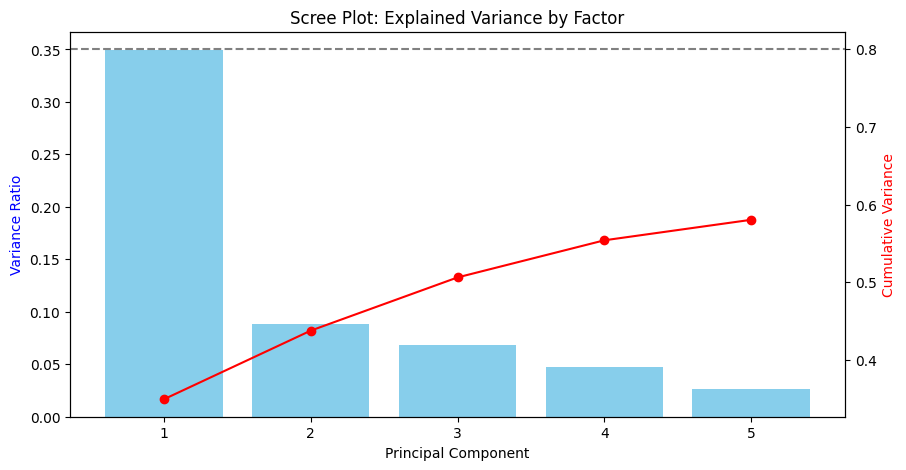

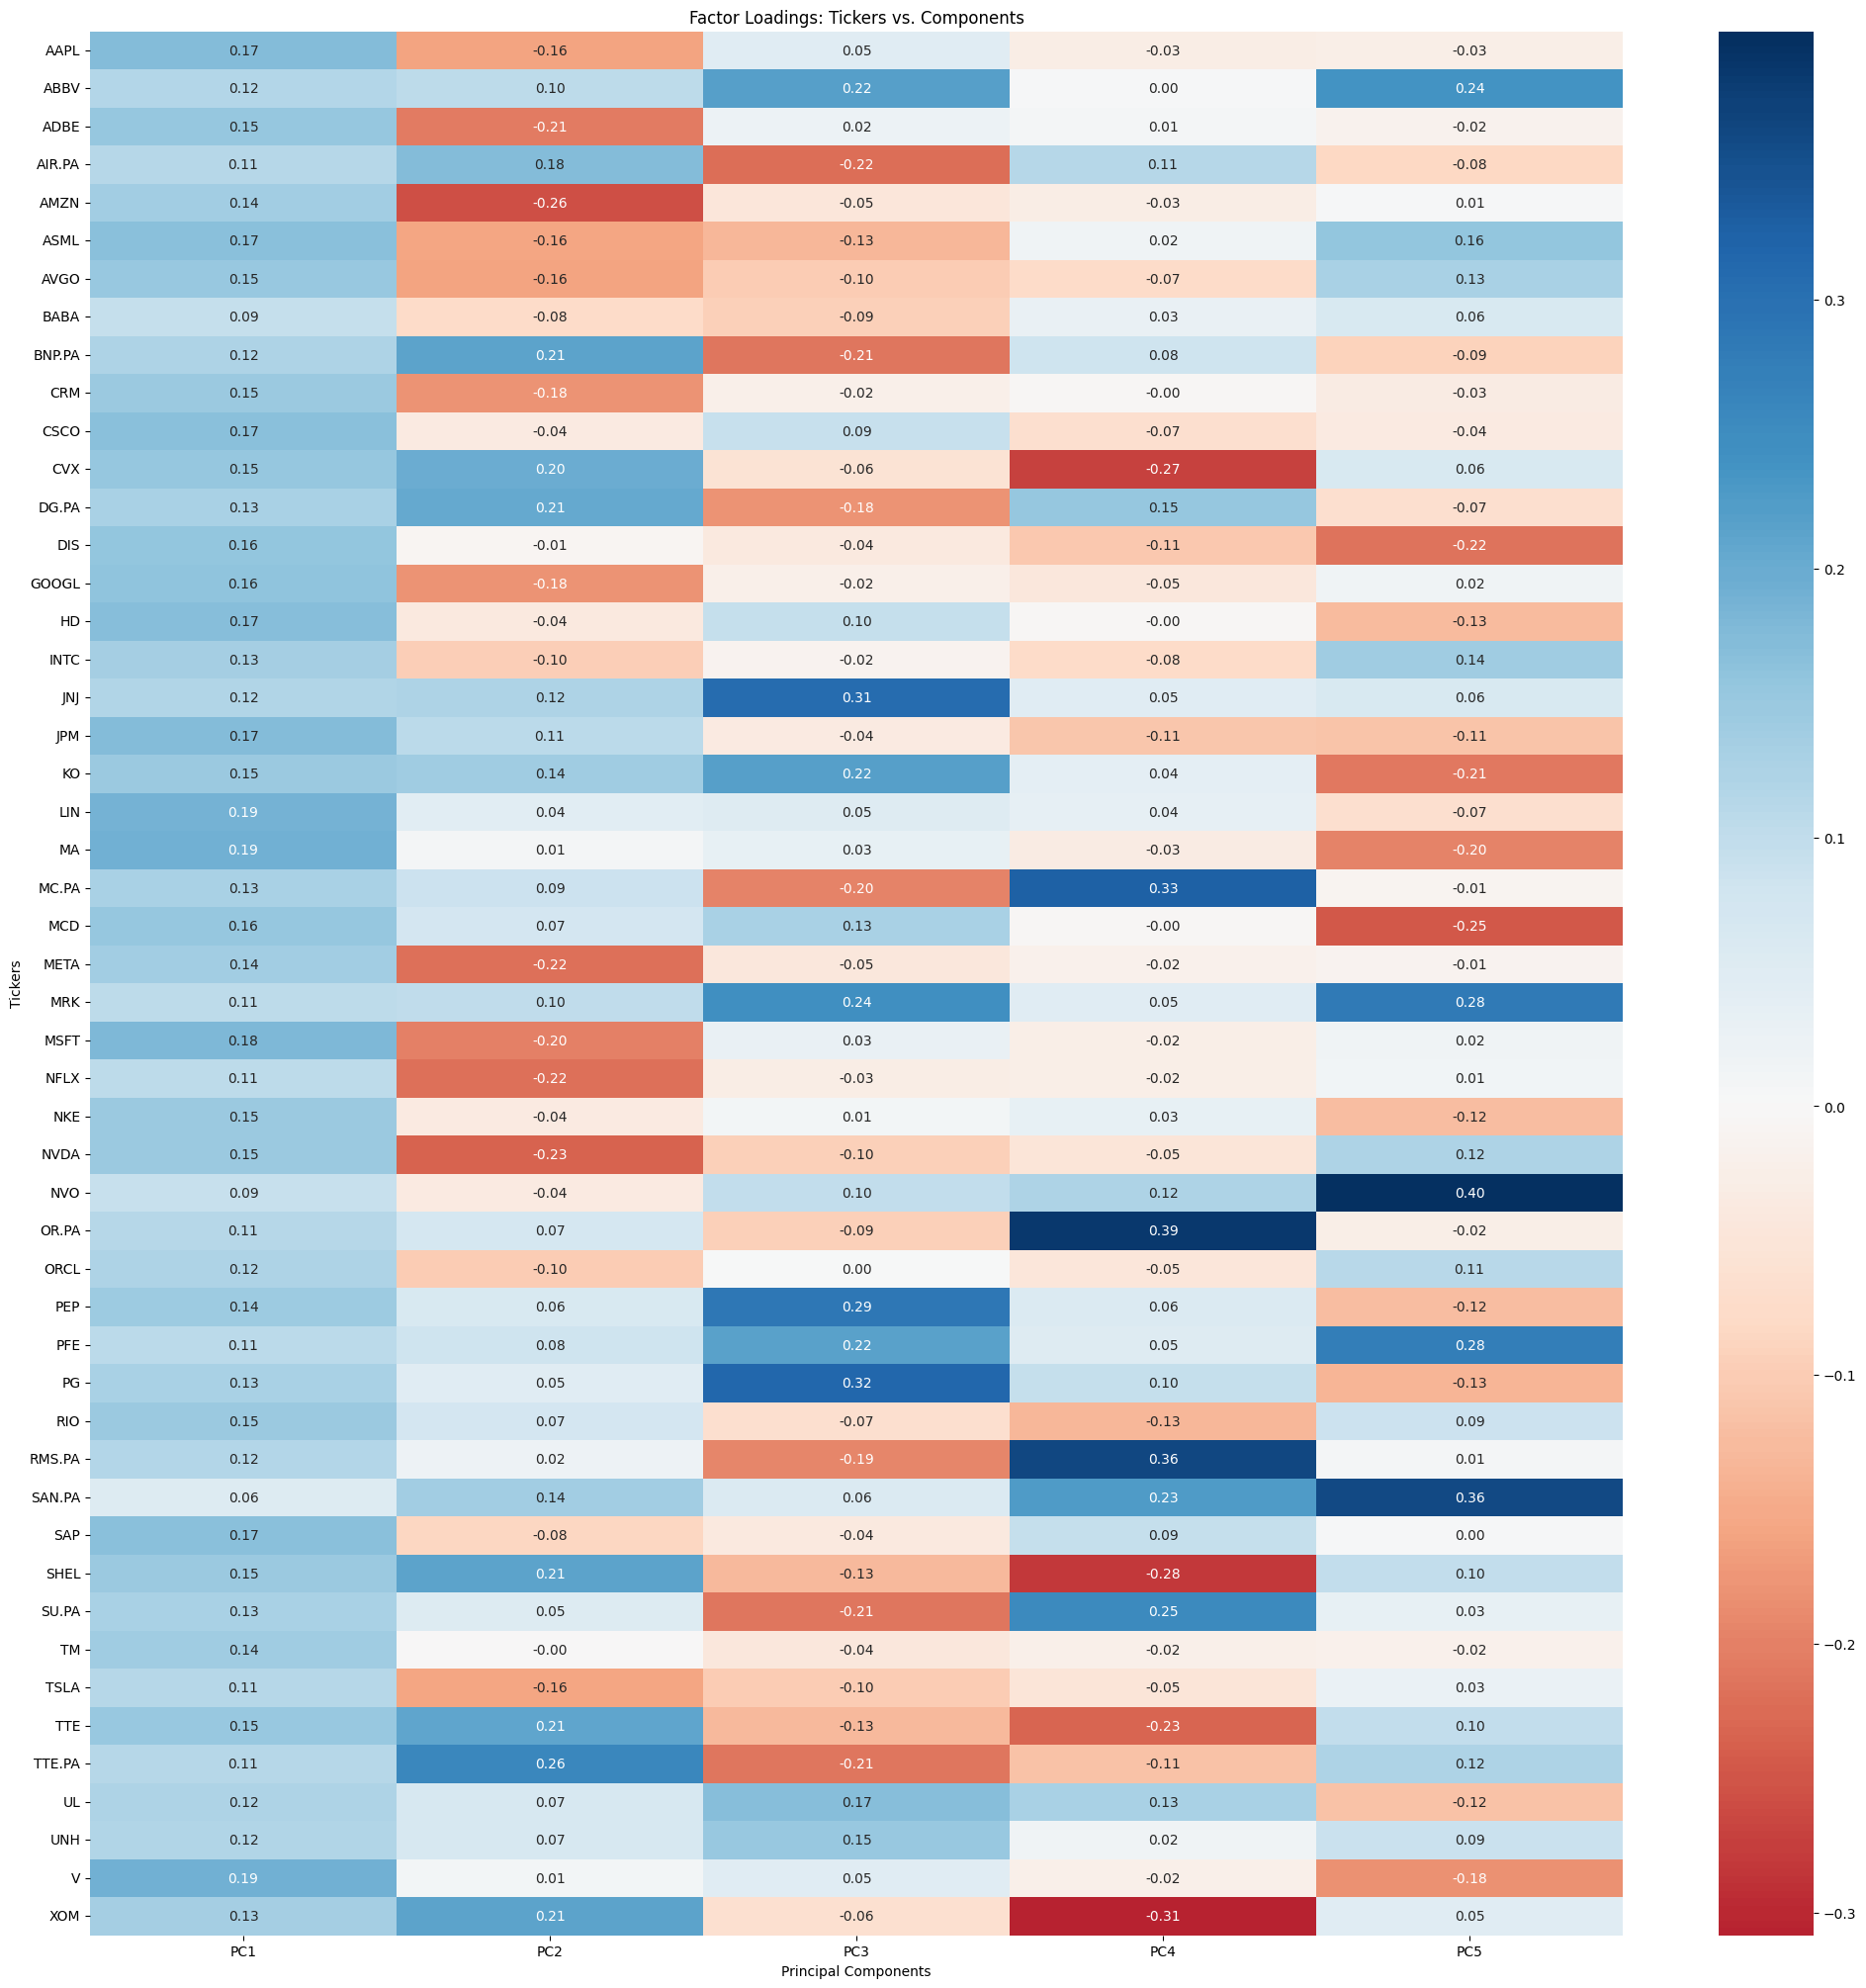

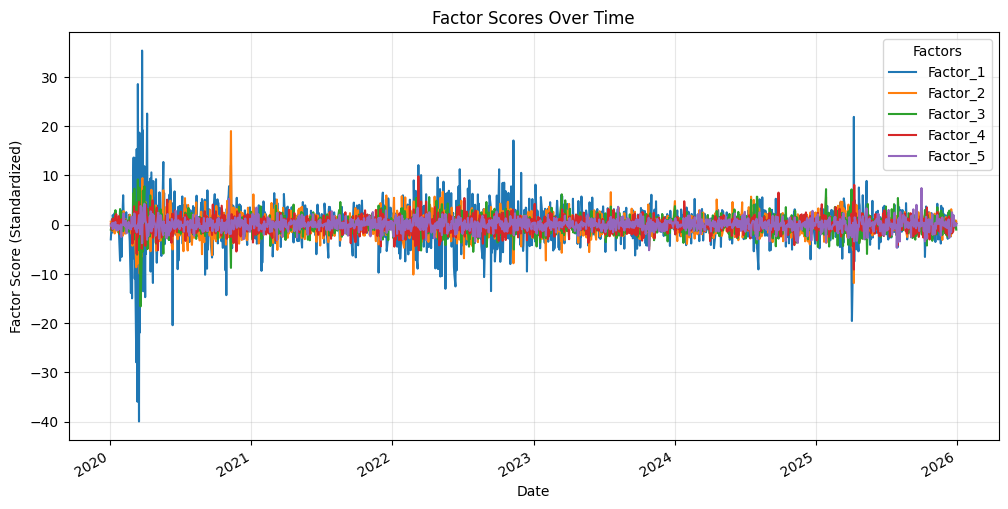

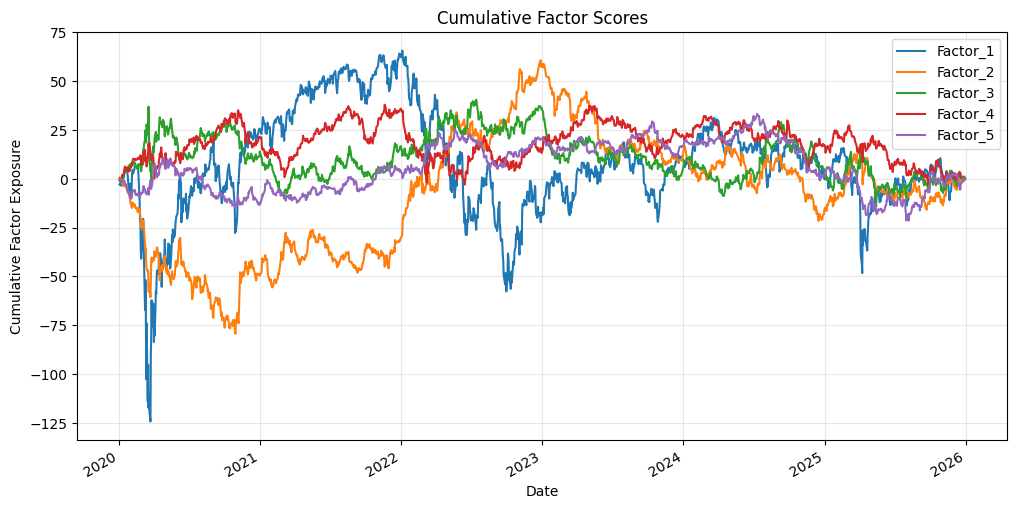

In [5]:
# 1. Initialize Engines
dm = DataManager()  # Uses default "data/raw" from project root
engine = FactorEngine()

# 2. Load tickers and verify
tickers = dm.list_existing_tickers()
print(f"Found {len(tickers)} tickers: {tickers}...")  # Show first 10

if len(tickers) == 0:
    raise ValueError("No tickers found! Check that data/raw directory contains ticker folders.")

# 3. Parameters
start_date = '2020-01-01'
end_date = '2025-12-31'
N_FACTORS = 5

# 4. Compute Factors
# Returns: factor_df (T x 5), loadings (N x 5), eigenvalues (5,)
print(f"Computing {N_FACTORS} factors for {len(tickers)} tickers...")
factor_df, loadings, eigenvalues, eigenvectors = engine.compute_pca_factors(
    tickers=tickers, 
    start_date=start_date, 
    end_date=end_date, 
    n_components=N_FACTORS
)
print(f"✓ Factors computed: {factor_df.shape[0]} days × {N_FACTORS} factors")



# ### Visualization 1: The Scree Plot
# Determining how many dimensions of risk actually matter.
exp_var = engine.get_explained_variance()
cum_var = np.cumsum(exp_var)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bars for individual PC variance
ax1.bar(range(1, len(exp_var) + 1), exp_var, color='skyblue', label='Individual Variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Ratio', color='blue')
ax1.set_title('Scree Plot: Explained Variance by Factor')

# Line for cumulative variance
ax2 = ax1.twinx()
ax2.plot(range(1, len(exp_var) + 1), cum_var, color='red', marker='o', label='Cumulative')
ax2.set_ylabel('Cumulative Variance', color='red')
ax2.axhline(y=0.8, color='gray', linestyle='--') # 80% Threshold

plt.show()


# ### Visualization 2: Factor Loadings Heatmap
# Identifying the "DNA" of each factor.


plt.figure(figsize=(25, 25))
sns.heatmap(loadings, cmap='RdBu', center=0, annot=True, fmt=".2f")
plt.title('Factor Loadings: Tickers vs. Components')
plt.ylabel('Tickers')
plt.xlabel('Principal Components')
plt.show()



# ### Analysis Tasks:
# 1. **PC1 (The Market):** Check if all loadings for PC1 are the same sign. 
#    This represents the systemic movement.
# 2. **PC2 (The Wedge):** Look for the largest positive and negative values in PC2. 
#    Does it separate Tech (AAPL/NVDA) from Energy (XOM/CVX)? 
# 3. **The Factor Returns:** Plot the `factor_df` to see which "Statistical Factor" 
#    performed best during the period.

# %%
# Option 1: Plot factor scores (shows factor activity over time)
factor_df.plot(figsize=(12, 6), title="Factor Scores Over Time")
plt.ylabel("Factor Score (Standardized)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend(title="Factors")
plt.show()

# Option 2: Cumulative sum of factor scores (shows accumulation pattern)
factor_df.cumsum().plot(figsize=(12, 6), title="Cumulative Factor Scores")
plt.ylabel("Cumulative Factor Exposure")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
from src.analytics.black_litterman import BlackLittermanModel
from src.analytics.mvo_optimizer import MeanVarianceOptimizer
from src.analytics.hrp_optimizer import HrpOptimizer

returns = dm.load_returns(tickers=tickers, start_date=start_date, end_date=end_date)
market_caps = dm.get_latest_market_cap(tickers)

mvo = MeanVarianceOptimizer(returns=returns)
bl_helper = BlackLittermanModel()
hrp = HrpOptimizer(returns=returns)

sigma_daily = mvo._apply_ledoit_wolf_shrinkage()
sigma_ann = sigma_daily * 252
sigma_daily_df = pd.DataFrame(sigma_daily, index=tickers, columns=tickers)
sigma_ann_df = pd.DataFrame(sigma_ann, index=tickers, columns=tickers)

mvo = MeanVarianceOptimizer(returns=returns)
bl_helper = BlackLittermanModel()
hrp = HrpOptimizer(returns=returns)

weights_mvo = mvo.find_tangency_portfolio(risk_free_rate=0.04, risk_free_rate_is_annual=True)["weights"]
if np.abs(weights_mvo.sum() - 1) > 1e-6:
    raise ValueError("weights_mvo must sum to 1")

bl_helper.add_view({"AAPL": 1.0}, 0.10, confidence_score=0.3)
bl_helper.add_view({"AAPL": 0.5, "MSFT": 0.5, "GOOGL": -1.0}, 0.02, confidence_score=0.5)
posterior_returns = bl_helper.get_posterior_returns(
            sigma_ann_df,
            tau = 0.025,
            market_caps=market_caps,
            benchmark_return=0.08
        )
weights_bl = mvo.solve(
            expected_returns=posterior_returns, 
            covariance=sigma_ann_df, 
            risk_aversion=bl_helper.lambda_reg
        )
if np.abs(weights_bl.sum() - 1) > 1e-6:
    raise ValueError("weights_bl must sum to 1")

sorted_indices = hrp.get_quasi_diag()
weights_hrp = hrp.get_rec_bisection(covariance_matrix=sigma_daily_df, sorted_indices=sorted_indices)
if np.abs(weights_hrp.sum() - 1) > 1e-6:
    raise ValueError("weights_hrp must sum to 1")

betas_mvo = engine.calculate_portfolio_betas(weights_mvo, engine.loading)
betas_bl = engine.calculate_portfolio_betas(weights_bl, engine.loading)
betas_hrp = engine.calculate_portfolio_betas(weights_hrp, engine.loading)


betas = pd.DataFrame({
    "MVO": betas_mvo,
    "BL": betas_bl,
    "HRP": betas_hrp
})

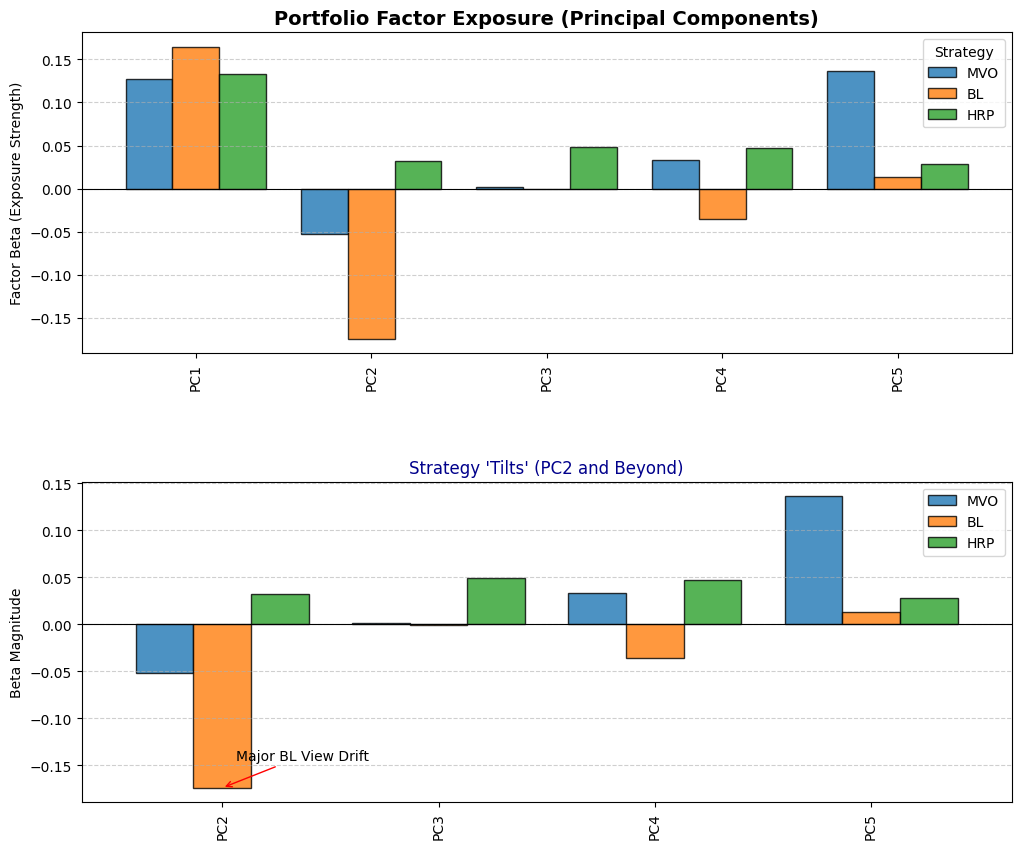

In [7]:
import matplotlib.pyplot as plt

def plot_factor_xray(betas_df):
    """
    betas_df: DataFrame with PCs as Index and Models (MVO, BL, HRP) as Columns
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)
    plt.subplots_adjust(hspace=0.4)

    # 1. Full Exposure (The "Beta" View)
    betas_df.plot(kind='bar', ax=ax1, width=0.8, alpha=0.8, edgecolor='black')
    ax1.set_title("Portfolio Factor Exposure (Principal Components)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Factor Beta (Exposure Strength)")
    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.grid(axis='y', linestyle='--', alpha=0.6)
    ax1.legend(title="Strategy")

    # 2. Tilt Exposure (Zooming in on PC2 onwards)
    # This is where your Black-Litterman 'Tech View' usually hides!
    tilt_betas = betas_df.iloc[1:]  # Exclude PC1
    tilt_betas.plot(kind='bar', ax=ax2, width=0.8, alpha=0.8, edgecolor='black')
    
    ax2.set_title("Strategy 'Tilts' (PC2 and Beyond)", fontsize=12, color='darkblue')
    ax2.set_ylabel("Beta Magnitude")
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Highlight the BL Spike (Optional/Manual annotation logic)
    # We can detect which PC has the max deviation for BL
    bl_tilt_max = tilt_betas['BL'].abs().idxmax()
    ax2.annotate('Major BL View Drift', 
                 xy=(tilt_betas.index.get_loc(bl_tilt_max), tilt_betas.loc[bl_tilt_max, 'BL']),
                 xytext=(10, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='red'))

    plt.show()

# Execute
plot_factor_xray(betas)

In [8]:
var_p_mvo = (betas_mvo**2).dot(eigenvalues)
var_p_bl = (betas_bl**2).dot(eigenvalues)
var_p_hrp = (betas_hrp**2).dot(eigenvalues)

var_p_daily = pd.DataFrame({
    "MVO": var_p_mvo,
    "BL": var_p_bl,
    "HRP": var_p_hrp
}, index=["Daily Variance"])

vol_ann = np.sqrt(var_p_daily * 252)
vol_ann.index = ["Annual Volatility"]

print(var_p_daily)

print(vol_ann)

                     MVO        BL       HRP
Daily Variance  0.000134  0.000267  0.000134
                        MVO        BL       HRP
Annual Volatility  0.183428  0.259168  0.183661


In [24]:
# 1. Setup Factor Vision
# Let's say we want Factor 2 to be nearly zero (neutralized)
factor_limits = {1: 0.1} # Factor index 1 is the 2nd Principal Component

# 2. Run Unconstrained Optimization (Max Sharpe)
unconstrained_res = mvo.find_tangency_portfolio(risk_free_rate=0.04)
w_unconstrained = unconstrained_res['weights']

# 3. Run Factor-Neutral Optimization (Max Sharpe + Vision)
neutral_res = mvo.find_tangency_portfolio(
    risk_free_rate=0.04,
    factor_exposure=eigenvectors, # Your SVD loadings
    factor_limits=factor_limits
)
w_neutral = neutral_res['weights']

w_neutral[np.isclose(w_neutral, 0, atol=1e-10)] = 0

w_neutral = w_neutral.sort_values(ascending=False)

w_neutral 

ABBV      0.363520
NVDA      0.271540
RMS.PA    0.164172
TSLA      0.104589
AVGO      0.090134
XOM       0.006044
AAPL      0.000000
ADBE      0.000000
AMZN      0.000000
AIR.PA    0.000000
CSCO      0.000000
CVX       0.000000
DG.PA     0.000000
DIS       0.000000
ASML      0.000000
BABA      0.000000
BNP.PA    0.000000
CRM       0.000000
JNJ       0.000000
INTC      0.000000
HD        0.000000
GOOGL     0.000000
MC.PA     0.000000
JPM       0.000000
LIN       0.000000
KO        0.000000
MRK       0.000000
MSFT      0.000000
NFLX      0.000000
NKE       0.000000
NVO       0.000000
MCD       0.000000
META      0.000000
MA        0.000000
PEP       0.000000
ORCL      0.000000
OR.PA     0.000000
PFE       0.000000
SAN.PA    0.000000
SAP       0.000000
PG        0.000000
RIO       0.000000
SU.PA     0.000000
SHEL      0.000000
TTE       0.000000
TM        0.000000
TTE.PA    0.000000
UL        0.000000
UNH       0.000000
V         0.000000
dtype: float64

In [8]:
# 1. Define a mid-range target return (e.g., 10-12% annual if applicable)
# Ensure units match your self.mu frequency!
target_ret = mvo.mu.mean() 

# 2. Unconstrained Mid-Return Portfolio
w_unconstrained = mvo.get_optimal_weights(target_return=target_ret)


# 3. Factor-Neutral Mid-Return Portfolio (Neutralize Factor 2)
# Tighten the limit to 0.01 to force a reaction
factor_limits = {3: 0} 

w_neutral = mvo.get_optimal_weights(
    target_return=target_ret,
    factor_exposure=eigenvectors,
    factor_limits=factor_limits
)

In [9]:
# Calculate attribution for both
attr_unconstrained = mvo.calculate_idiosyncratic_risk(
    w_unconstrained.to_dict(), eigenvectors
)

attr_neutral = mvo.calculate_idiosyncratic_risk(
    w_neutral.to_dict(), eigenvectors
)

# Display the comparison
comparison = pd.concat([attr_unconstrained, attr_neutral], keys=['Unconstrained', 'Factor-Neutral'])
print(comparison)

w_unconstrained[np.isclose(w_unconstrained, 0, atol=1e-10)] = 0
w_unconstrained = w_unconstrained.sort_values(ascending=False)

w_neutral[np.isclose(w_neutral, 0, atol=1e-10)] = 0
w_neutral = w_neutral.sort_values(ascending=False)



                         Factor_Risk  Idiosyncratic_Risk
Unconstrained  Variance     0.000072            0.000010
Factor-Neutral Variance     0.000082            0.000009
